# SA2: YOLOv26 Object Detection — Training & Evaluation
**TRY1_DataScience3_DelaCruz-Zabala** — v1 2026-02-28

## Table of Contents
1. Environment Setup
2. Dataset Verification
3. Model Initialization & Training (3 Configurations)
4. Model Evaluation — Confusion Matrices
5. Performance Metrics Table
6. Discussion & Comparison

---
## 1. Environment Setup

In [ ]:
# Mount Google Drive & install dependencies
# force_remount=True lets you pick a different Google account each time
from google.colab import drive
drive.mount('/content/drive', force_remount=True)



Mounted at /content/drive


In [ ]:
!pip install -U ultralytics
!pip install pandas matplotlib seaborn opencv-python-headless pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00


In [ ]:
import os
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO, settings

sns.set_theme(style="whitegrid", palette="muted")

# ── Google Drive base paths ──
DRIVE_BASE = Path("/content/drive/MyDrive/DataSci 3/DataSci3_Datasets")
BALANCED_DIR = DRIVE_BASE / "Balanced"
NOAUG_DIR    = DRIVE_BASE / "NoAug"
RUNS_DIR     = Path("/content/drive/MyDrive/DataSci 3/DataSci3_Runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Balanced dataset : {BALANCED_DIR}  (exists={BALANCED_DIR.exists()})")
print(f"NoAug dataset    : {NOAUG_DIR}  (exists={NOAUG_DIR.exists()})")
print(f"Runs output dir  : {RUNS_DIR}")

# Print versions for reproducibility
import ultralytics
print(f"\nUltralytics version: {ultralytics.__version__}")
print("Setup complete.")

Balanced dataset : /content/drive/MyDrive/DataSci 3/DataSci3_Datasets/Balanced  (exists=True)
NoAug dataset    : /content/drive/MyDrive/DataSci 3/DataSci3_Datasets/NoAug  (exists=True)
Runs output dir  : /content/drive/MyDrive/DataSci 3/DataSci3_Runs

Ultralytics version: 8.4.18
Setup complete.


---
## 2. Dataset Verification

We use the **Balanced** dataset produced by SA1 (augmentation-based oversampling).

In [ ]:
DATA_YAML = BALANCED_DIR / "data.yaml"

# Verify data.yaml exists and print contents
assert DATA_YAML.exists(), f"{DATA_YAML} not found — upload dataset to Google Drive first."

with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

print("=== data.yaml ===")
for k, v in data_cfg.items():
    print(f"  {k}: {v}")

CLASS_NAMES = data_cfg["names"]
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")

=== data.yaml ===
  names: ['Bicycle', 'Car', 'Jeepney', 'Pedestrian', 'SUV', 'Tricycle', 'Truck']
  nc: 7
  roboflow: {'license': 'Private', 'project': 'try1_datascience3_delacruz-zabala', 'url': 'https://app.roboflow.com/ralf-cedrics-workspace/try1_datascience3_delacruz-zabala/2', 'version': 2, 'workspace': 'ralf-cedrics-workspace'}
  test: test/images
  train: train/images
  val: valid/images

Classes (7): ['Bicycle', 'Car', 'Jeepney', 'Pedestrian', 'SUV', 'Tricycle', 'Truck']


In [ ]:
# Quick sanity check — count images per split
for split_key, folder_name in [("train", "train"), ("val", "valid"), ("test", "test")]:
    img_dir = BALANCED_DIR / folder_name / "images"
    n = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"  [{folder_name:>5}]  images: {n}")

  [train]  images: 1010
  [valid]  images: 154
  [ test]  images: 146


In [ ]:
import glob
n_aug = len(glob.glob(str(BALANCED_DIR / "train/images/aug_*.jpg")))
n_total = len(glob.glob(str(BALANCED_DIR / "train/images/*")))
print(f"Original: {n_total - n_aug}, Augmented: {n_aug}, Total: {n_total}")

Original: 705, Augmented: 305, Total: 1010


In [ ]:
from collections import Counter
from pathlib import Path

lbl_dir = BALANCED_DIR / "train" / "labels"
counts = Counter()
for lbl_file in lbl_dir.glob("*.txt"):
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                counts[int(float(parts[0]))] += 1

for cls_id in sorted(counts):
    print(f"  Class {cls_id}: {counts[cls_id]} annotations")

median = sorted(counts.values())[len(counts) // 2]
print(f"\nMedian: {median}")
print(f"Min: {min(counts.values())}, Max: {max(counts.values())}")
print(f"Imbalance ratio: {max(counts.values()) / min(counts.values()):.2f}")

  Class 0: 1581 annotations
  Class 1: 709 annotations
  Class 2: 635 annotations
  Class 3: 653 annotations
  Class 4: 1225 annotations
  Class 5: 566 annotations
  Class 6: 539 annotations

Median: 653
Min: 539, Max: 1581
Imbalance ratio: 2.93


---
## 3. Model Initialization & Training

We train **3 YOLOv26n models**, each with a distinct hyperparameter configuration:

| Config | Epochs | Image Size | Optimizer | Batch | Learning Rate |
|--------|--------|------------|-----------|-------|---------------|
| Model A | 25 | 640 | AdamW | 4 | 0.01 |
| Model B | 30 | 640 | SGD | 20 | 0.001 |
| Model C | 40 | 640 | auto | -1 (auto) | 0.0001 |

In [ ]:
# Define the 3 training configurations
configs = {
    "Model_A": {
        "epochs": 25,
        "imgsz": 640,
        "optimizer": "AdamW",
        "batch": 4,
        "lr0": 0.01,
    },
    "Model_B": {
        "epochs": 30,
        "imgsz": 640,
        "optimizer": "SGD",
        "batch": 20,
        "lr0": 0.001,
    },
    "Model_C": {
        "epochs": 40,
        "imgsz": 640,
        "optimizer": "auto",
        "batch": -1,
        "lr0": 0.0001,
    },
}

# Display hyperparameter table
hyper_df = pd.DataFrame(configs).T
hyper_df.index.name = "Model"
hyper_df = hyper_df.reset_index()
print("=== Hyperparameter Configurations ===")
print(hyper_df.to_string(index=False))

=== Hyperparameter Configurations ===
  Model epochs imgsz optimizer batch     lr0
Model_A     25   640     AdamW     4    0.01
Model_B     30   640       SGD    20   0.001
Model_C     40   640      auto    -1  0.0001


### 3.1 Train Model A — AdamW, 25 epochs, batch 4, lr 0.01

In [ ]:
import yaml
from pathlib import Path

yaml_path = BALANCED_DIR / "data.yaml"
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

# Use paths relative to data.yaml's parent (BALANCED_DIR)
data["path"] = str(BALANCED_DIR)
data["train"] = "train/images"
data["val"]   = "valid/images"
data["test"]  = "test/images"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, default_flow_style=False)

print("Fixed data.yaml paths:")
for k in ["path", "train", "val", "test"]:
    print(f"  {k}: {data[k]}")

Fixed data.yaml paths:
  path: /content/drive/MyDrive/DataSci 3/DataSci3_Datasets/Balanced
  train: train/images
  val: valid/images
  test: test/images


In [ ]:
model_a = YOLO("yolo26n.pt")

results_a = model_a.train(
    data=str(DATA_YAML),
    epochs=configs["Model_A"]["epochs"],
    imgsz=configs["Model_A"]["imgsz"],
    optimizer=configs["Model_A"]["optimizer"],
    batch=configs["Model_A"]["batch"],
    lr0=configs["Model_A"]["lr0"],
    project=str(RUNS_DIR / "detect"),
    name="Model_A",
    exist_ok=True,
    verbose=True,
)

print("\nModel A training complete.")
print(f"Best weights: {model_a.trainer.best}")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DataSci 3/DataSci3_Datasets/Balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Model_A, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, ove

### 3.2 Train Model B — SGD, 30 epochs, batch 20, lr 0.001

In [ ]:
model_b = YOLO("yolo26n.pt")

results_b = model_b.train(
    data=str(DATA_YAML),
    epochs=configs["Model_B"]["epochs"],
    imgsz=configs["Model_B"]["imgsz"],
    optimizer=configs["Model_B"]["optimizer"],
    batch=configs["Model_B"]["batch"],
    lr0=configs["Model_B"]["lr0"],
    project=str(RUNS_DIR / "detect"),
    name="Model_B",
    exist_ok=True,
    verbose=True,
)

print("\nModel B training complete.")
print(f"Best weights: {model_b.trainer.best}")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=20, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DataSci 3/DataSci3_Datasets/Balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Model_B, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, ove

### 3.3 Train Model C — auto optimizer, 40 epochs, auto-batch, lr 0.0001

In [ ]:
model_c = YOLO("yolo26n.pt")

results_c = model_c.train(
    data=str(DATA_YAML),
    epochs=configs["Model_C"]["epochs"],
    imgsz=configs["Model_C"]["imgsz"],
    optimizer=configs["Model_C"]["optimizer"],
    batch=configs["Model_C"]["batch"],
    lr0=configs["Model_C"]["lr0"],
    project=str(RUNS_DIR / "detect"),
    name="Model_C",
    exist_ok=True,
    verbose=True,
)

print("\nModel C training complete.")
print(f"Best weights: {model_c.trainer.best}")

New https://pypi.org/project/ultralytics/8.4.19 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/DataSci 3/DataSci3_Datasets/Balanced/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic

---
## 4. Model Evaluation — Confusion Matrices

Each training run saves a `confusion_matrix.png` and
`confusion_matrix_normalized.png` in its output directory.
We display them here for analysis.

In [ ]:
# Helper to locate and display the confusion matrix
def show_confusion_matrix(run_dir, title):
    """Display the confusion matrix image from a training run."""
    cm_path = Path(run_dir) / "confusion_matrix_normalized.png"
    if not cm_path.exists():
        cm_path = Path(run_dir) / "confusion_matrix.png"
    if not cm_path.exists():
        print(f"  [!] Confusion matrix not found in {run_dir}")
        return

    img = mpimg.imread(str(cm_path))
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

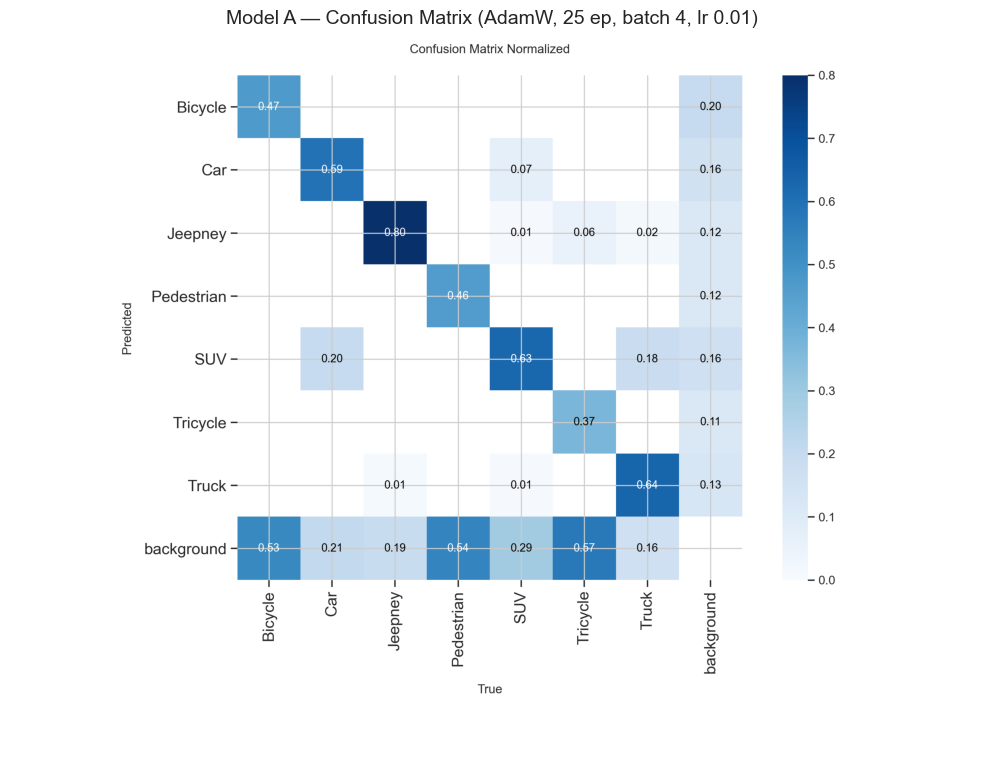

In [ ]:
show_confusion_matrix(str(RUNS_DIR / "detect/Model_A"), "Model A — Confusion Matrix (AdamW, 25 ep, batch 4, lr 0.01)")

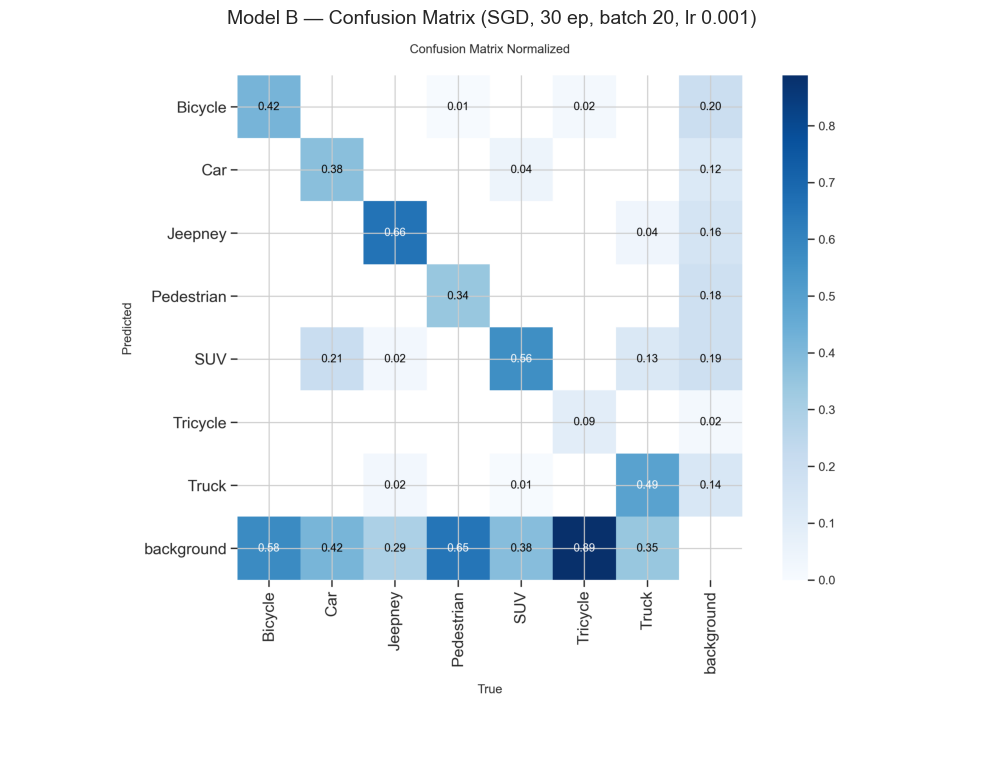

In [ ]:
show_confusion_matrix(str(RUNS_DIR / "detect/Model_B"), "Model B — Confusion Matrix (SGD, 30 ep, batch 20, lr 0.001)")

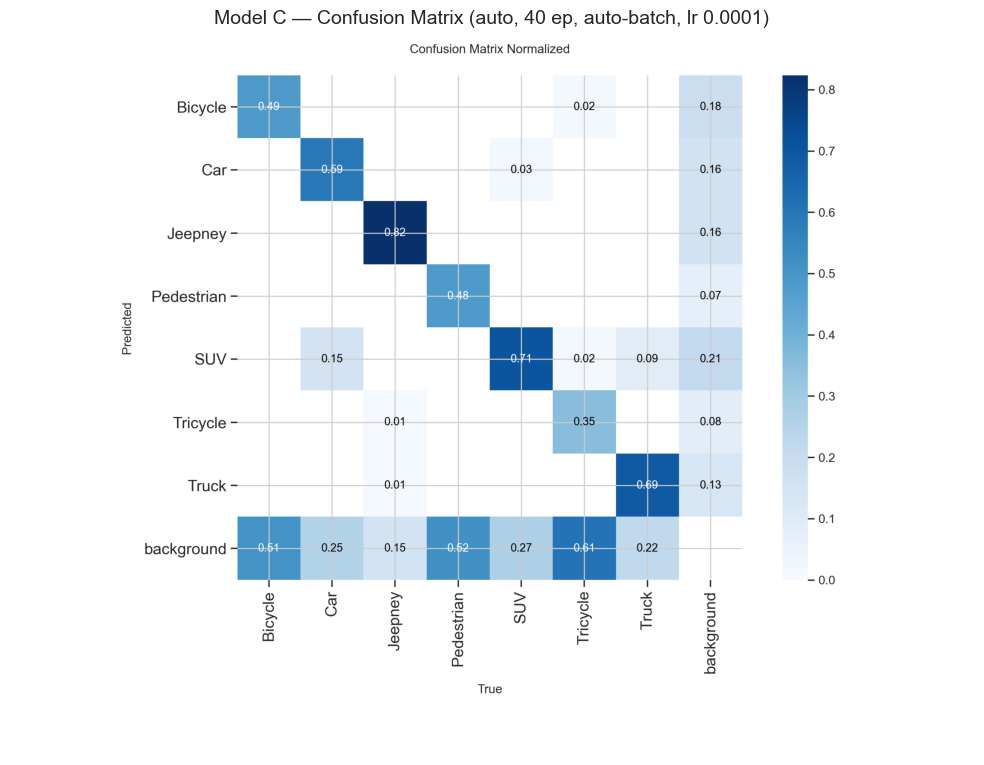

In [ ]:
show_confusion_matrix(str(RUNS_DIR / "detect/Model_C"), "Model C — Confusion Matrix (auto, 40 ep, auto-batch, lr 0.0001)")

### Confusion Matrix Analysis

For each matrix above, examine:
- **Diagonal values (True Positives):** Higher values = the model correctly identifies that class.
- **Off-diagonal values (Misclassifications):** Which classes are confused with each other.
- **"background" column/row (False Positives / False Negatives):** The model is either hallucinating objects or missing real objects.

Detailed per-model discussion is provided in Section 6.

---
## 5. Performance Metrics Table

We run `model.val()` on each model's best weights and extract:
- **mAP50** (mean Average Precision at IoU=0.50 — accuracy proxy)
- **Precision**
- **Recall**
- **F1 Score** (harmonic mean of Precision and Recall)

In [ ]:
def evaluate_model(weights_path, data_yaml, model_name):
    """Run validation and return a dict of aggregate + per-class metrics."""
    model = YOLO(weights_path)
    metrics = model.val(data=str(data_yaml), verbose=False)

    precision = metrics.box.mp
    recall = metrics.box.mr
    map50 = metrics.box.map50
    f1 = (2 * precision * recall) / (precision + recall + 1e-9)

    result = {
        "Model": model_name,
        "mAP50": round(map50, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
    }

    per_class = []
    for i, cls_name in enumerate(CLASS_NAMES):
        p = metrics.box.p[i] if i < len(metrics.box.p) else 0
        r = metrics.box.r[i] if i < len(metrics.box.r) else 0
        ap50 = metrics.box.ap50[i] if i < len(metrics.box.ap50) else 0
        cls_f1 = (2 * p * r) / (p + r + 1e-9)
        per_class.append({
            "Model": model_name,
            "Class": cls_name,
            "AP50": round(ap50, 4),
            "Precision": round(p, 4),
            "Recall": round(r, 4),
            "F1 Score": round(cls_f1, 4),
        })

    return result, per_class, metrics

In [ ]:
#Evaluate Model A

print("Evaluating Model A ...")
agg_a, cls_a, _ = evaluate_model(str(RUNS_DIR / "detect/Model_A/weights/best.pt"), DATA_YAML, "Model_A")
print(f"  mAP50={agg_a['mAP50']}  P={agg_a['Precision']}  R={agg_a['Recall']}  F1={agg_a['F1 Score']}")

Evaluating Model A ...
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 2.9±5.0 ms, read: 20.3±11.8 MB/s, size: 70.8 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1hWpH65Qjr1czwgJk2tnC7aeytyahqjsf/DataSci 3/DataSci3_Datasets/Balanced/valid/labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 43.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.3it/s 4.4s
                   all        154        978      0.668      0.527      0.603       0.32
Speed: 3.8ms preprocess, 6.5ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
  mAP50=0.6034  P=0.6682  R=0.5274  F1=0.5895


In [ ]:
#Evaluate Model B

print("Evaluating Model B ...")
agg_b, cls_b, _ = evaluate_model(str(RUNS_DIR / "detect/Model_B/weights/best.pt"), DATA_YAML, "Model_B")
print(f"  mAP50={agg_b['mAP50']}  P={agg_b['Precision']}  R={agg_b['Recall']}  F1={agg_b['F1 Score']}")

Evaluating Model B ...
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.2 ms, read: 35.3±12.9 MB/s, size: 70.8 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1hWpH65Qjr1czwgJk2tnC7aeytyahqjsf/DataSci 3/DataSci3_Datasets/Balanced/valid/labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 46.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.3it/s 4.4s
                   all        154        978      0.501      0.503      0.486      0.286
Speed: 2.7ms preprocess, 6.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val2
  mAP50=0.4858  P=0.5007  R=0.5029  F1=0.5018


In [ ]:
# Evaluate Model C

print("Evaluating Model C ...")
agg_c, cls_c, _ = evaluate_model(str(RUNS_DIR / "detect/Model_C/weights/best.pt"), DATA_YAML, "Model_C")
print(f"  mAP50={agg_c['mAP50']}  P={agg_c['Precision']}  R={agg_c['Recall']}  F1={agg_c['F1 Score']}")

Evaluating Model C ...
Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.7 ms, read: 34.4±20.8 MB/s, size: 73.2 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1hWpH65Qjr1czwgJk2tnC7aeytyahqjsf/DataSci 3/DataSci3_Datasets/Balanced/valid/labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 154/154 46.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.8it/s 5.5s
                   all        154        978       0.65      0.591      0.618      0.369
Speed: 5.7ms preprocess, 8.4ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /content/runs/detect/val3
  mAP50=0.6178  P=0.65  R=0.5911  F1=0.6192


In [ ]:
# Combine results

agg_results = [agg_a, agg_b, agg_c]
cls_results = cls_a + cls_b + cls_c

In [ ]:
# --- 5.1  Hyperparameter Settings Table ---
print("=" * 65)
print("TABLE 1: Hyperparameter Configurations")
print("=" * 65)
hyper_df = pd.DataFrame(configs).T.reset_index().rename(columns={"index": "Model"})
hyper_df.columns = ["Model", "Epochs", "Image Size", "Optimizer", "Batch Size", "Learning Rate"]
print(hyper_df.to_string(index=False))
hyper_df

TABLE 1: Hyperparameter Configurations
  Model Epochs Image Size Optimizer Batch Size Learning Rate
Model_A     25        640     AdamW          4          0.01
Model_B     30        640       SGD         20         0.001
Model_C     40        640      auto         -1        0.0001


,Model,Epochs,Image Size,Optimizer,Batch Size,Learning Rate
0,Model_A,25,640,AdamW,4,0.01
1,Model_B,30,640,SGD,20,0.001
2,Model_C,40,640,auto,-1,0.0001


In [ ]:
# --- 5.2  Aggregate Metrics Table ---
print("=" * 65)
print("TABLE 2: Model Performance Metrics (Aggregate)")
print("=" * 65)
metrics_df = pd.DataFrame(agg_results)
print(metrics_df.to_string(index=False))
metrics_df

TABLE 2: Model Performance Metrics (Aggregate)
  Model  mAP50  Precision  Recall  F1 Score
Model_A 0.6034     0.6682  0.5274    0.5895
Model_B 0.4858     0.5007  0.5029    0.5018
Model_C 0.6178     0.6500  0.5911    0.6192


,Model,mAP50,Precision,Recall,F1 Score
0,Model_A,0.6034,0.6682,0.5274,0.5895
1,Model_B,0.4858,0.5007,0.5029,0.5018
2,Model_C,0.6178,0.6500,0.5911,0.6192


In [ ]:
# --- 5.3  Per-Class Metrics Table ---
print("=" * 70)
print("TABLE 3: Per-Class Performance Metrics")
print("=" * 70)
cls_df = pd.DataFrame(cls_results)
print(cls_df.to_string(index=False))
cls_df

TABLE 3: Per-Class Performance Metrics
  Model      Class   AP50  Precision  Recall  F1 Score
Model_A    Bicycle 0.5896     0.8425  0.4077    0.5495
Model_A        Car 0.6667     0.6130  0.5660    0.5886
Model_A    Jeepney 0.7987     0.6981  0.8000    0.7456
Model_A Pedestrian 0.5836     0.7903  0.4194    0.5480
Model_A        SUV 0.6207     0.6273  0.6026    0.6147
Model_A   Tricycle 0.3513     0.5361  0.2778    0.3659
Model_A      Truck 0.6130     0.5697  0.6182    0.5930
Model_B    Bicycle 0.5249     0.6605  0.4690    0.5485
Model_B        Car 0.5584     0.5355  0.5000    0.5171
Model_B    Jeepney 0.6813     0.5691  0.7457    0.6455
Model_B Pedestrian 0.4510     0.5681  0.4355    0.4930
Model_B        SUV 0.5684     0.4682  0.6218    0.5341
Model_B   Tricycle 0.1732     0.3206  0.1481    0.2027
Model_B      Truck 0.4431     0.3828  0.6000    0.4674
Model_C    Bicycle 0.5727     0.7665  0.4702    0.5829
Model_C        Car 0.6471     0.6275  0.6038    0.6154
Model_C    Jeepney 0.7647 

,Model,Class,AP50,Precision,Recall,F1 Score
0,Model_A,Bicycle,0.5896,0.8425,0.4077,0.5495
1,Model_A,Car,0.6667,0.6130,0.5660,0.5886
2,Model_A,Jeepney,0.7987,0.6981,0.8000,0.7456
3,Model_A,Pedestrian,0.5836,0.7903,0.4194,0.5480
4,Model_A,SUV,0.6207,0.6273,0.6026,0.6147
5,Model_A,Tricycle,0.3513,0.5361,0.2778,0.3659
6,Model_A,Truck,0.6130,0.5697,0.6182,0.5930
7,Model_B,Bicycle,0.5249,0.6605,0.4690,0.5485
8,Model_B,Car,0.5584,0.5355,0.5000,0.5171
9,Model_B,Jeepney,0.6813,0.5691,0.7457,0.6455


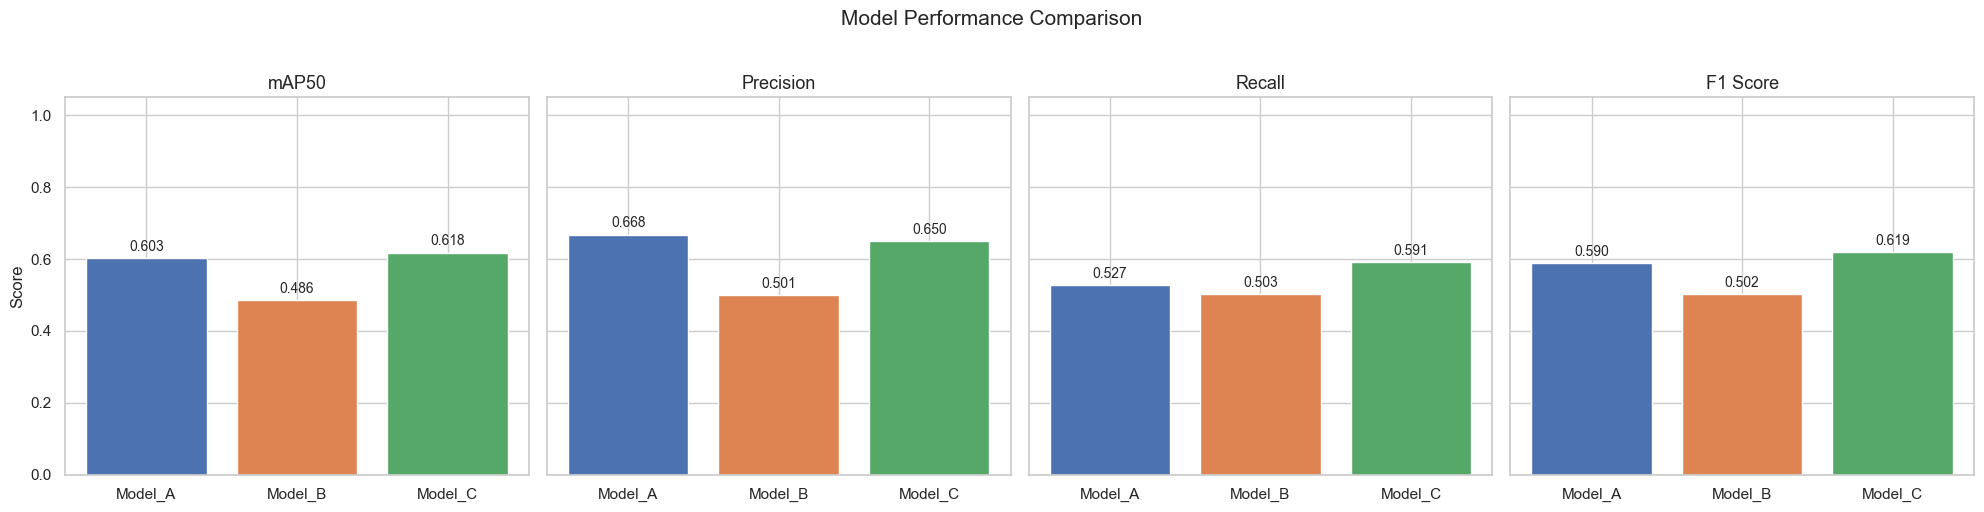

In [ ]:
# --- 5.4  Visual comparison bar chart ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
metric_cols = ["mAP50", "Precision", "Recall", "F1 Score"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metric_cols):
    bars = ax.bar(metrics_df["Model"], metrics_df[metric], color=colors)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score" if metric == metric_cols[0] else "")
    for bar, val in zip(bars, metrics_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.02,
            f"{val:.3f}",
            ha="center",
            fontsize=10,
            fontweight="bold",
        )

fig.suptitle("Model Performance Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

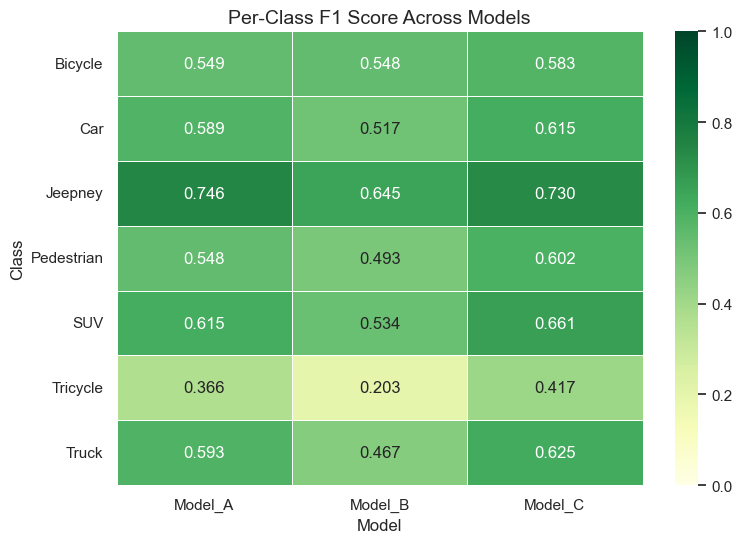

In [ ]:
# --- 5.5  Per-class F1 heatmap ---
pivot = cls_df.pivot(index="Class", columns="Model", values="F1 Score")

fig, ax = plt.subplots(figsize=(8, max(4, NUM_CLASSES * 0.8)))
sns.heatmap(
    pivot, annot=True, fmt=".3f", cmap="YlGn",
    vmin=0, vmax=1, linewidths=0.5, ax=ax,
)
ax.set_title("Per-Class F1 Score Across Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()